In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Seaborn version:", sns.__version__)

Pandas version: 3.0.2
NumPy version: 2.4.4
Matplotlib version: 3.10.9
Seaborn version: 0.13.2


In [2]:
# Load the CIPLA stock price dataset

df = pd.read_csv("CIPLA.csv")

# Show dataset shape and first five rows
print("Dataset shape:", df.shape)
df.head(5)

Dataset shape: (5306, 15)


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,CIPLA,EQ,1349.40,1410.0,1457.35,1380.05,1457.35,1457.35,1441.36,21060,3.035496e+12,NaN,NaN,NaN
1,2000-01-04,CIPLA,EQ,1457.35,1537.0,1537.00,1430.00,1466.05,1465.25,1460.43,30215,4.412698e+12,NaN,NaN,NaN
2,2000-01-05,CIPLA,EQ,1465.25,1474.0,1474.00,1365.00,1441.00,1435.05,1428.11,33799,4.826872e+12,NaN,NaN,NaN
3,2000-01-06,CIPLA,EQ,1435.05,1434.0,1435.00,1349.00,1365.00,1355.85,1390.55,33083,4.600356e+12,NaN,NaN,NaN
4,2000-01-07,CIPLA,EQ,1355.85,1370.0,1389.90,1247.40,1247.40,1247.55,1267.49,66536,8.433351e+12,NaN,NaN,NaN


In [6]:
# Data understanding and audit part 1

print("Columns in the dataset:")
print(df.columns)

print("\nDataset information:")
df.info()

Columns in the dataset:
Index(['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last',
       'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume',
       '%Deliverble'],
      dtype='str')

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 5306 entries, 0 to 5305
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                5306 non-null   str    
 1   Symbol              5306 non-null   str    
 2   Series              5306 non-null   str    
 3   Prev Close          5306 non-null   float64
 4   Open                5306 non-null   float64
 5   High                5306 non-null   float64
 6   Low                 5306 non-null   float64
 7   Last                5306 non-null   float64
 8   Close               5306 non-null   float64
 9   VWAP                5306 non-null   float64
 10  Volume              5306 non-null   int64  
 11  Turnover        

In [ ]:
# Data understanding and audit part 2
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nSummary Statistics:")
display(df.describe())


Missing Values:
Date                     0
Symbol                   0
Series                   0
Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                2850
Deliverable Volume     514
%Deliverble            514
dtype: int64

Duplicate Rows:
0

Summary Statistics:


,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
count,5306.000000,5306.000000,5306.000000,5306.000000,5306.000000,5306.000000,5306.000000,5.306000e+03,5.306000e+03,2456.000000,4.792000e+03,4792.000000
mean,540.503798,541.457755,549.587693,532.143583,540.472588,540.421052,540.931589,1.550071e+06,7.841696e+13,44967.250407,7.408486e+05,0.509209
std,289.319810,289.955959,295.087710,283.868905,289.158087,289.151156,289.411215,2.317962e+06,1.620908e+14,43776.047324,7.339493e+05,0.154639
min,160.100000,150.550000,169.450000,145.000000,152.000000,160.100000,158.140000,5.050000e+02,5.400606e+10,613.000000,2.013000e+03,0.069300
25%,309.025000,309.962500,312.750000,305.350000,309.000000,309.025000,309.290000,3.790408e+05,1.447839e+13,21724.000000,2.831312e+05,0.404575
50%,473.850000,474.625000,479.950000,468.875000,473.525000,473.850000,475.215000,1.047786e+06,3.725861e+13,32967.000000,5.787145e+05,0.516650
75%,681.937500,683.225000,691.787500,671.675000,681.937500,681.937500,682.035000,1.815542e+06,7.848478e+13,50869.500000,9.761000e+05,0.615125
max,1465.250000,1537.000000,1537.000000,1430.000000,1466.050000,1465.250000,1460.430000,5.689556e+07,4.498902e+15,603361.000000,1.081558e+07,0.994500


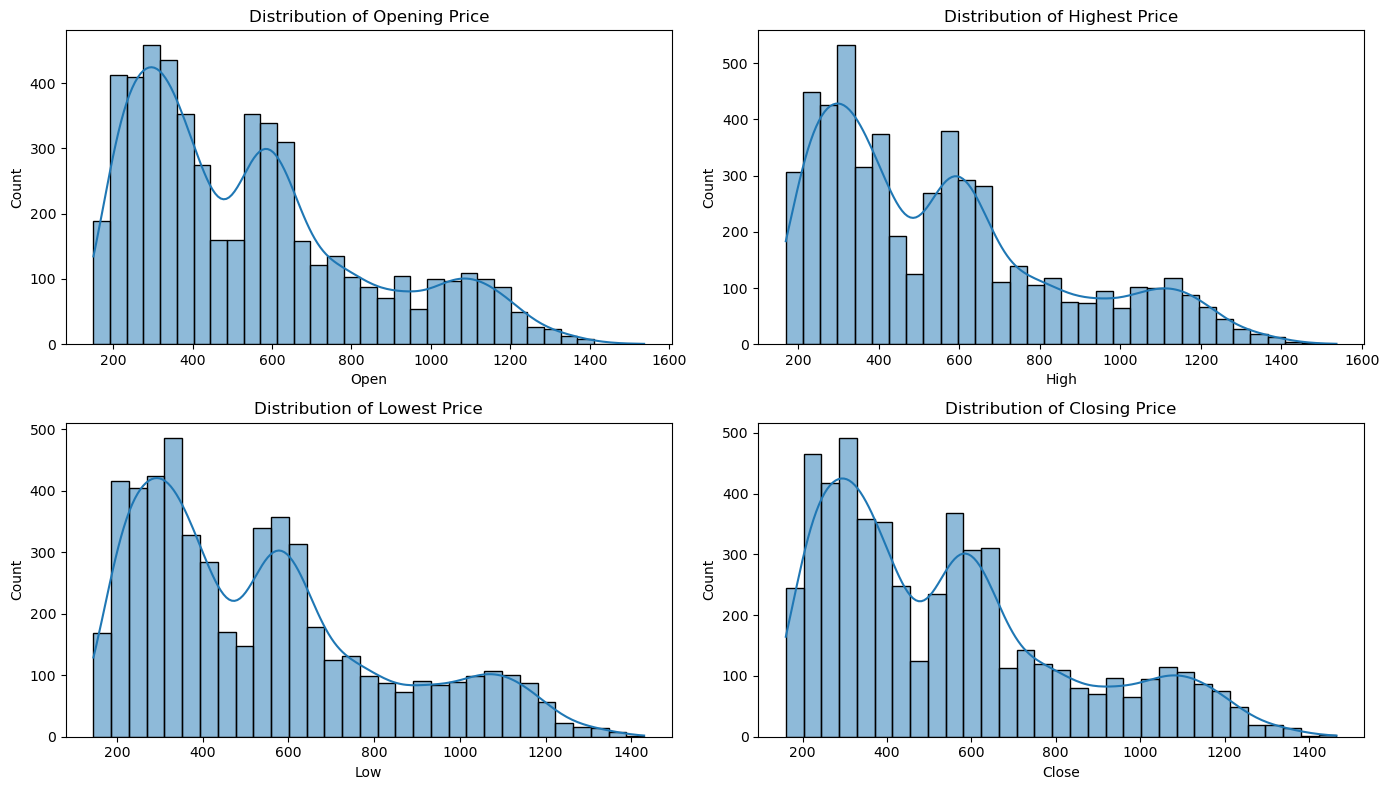

In [8]:
# EDA: Distribution of important stock price columns

plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
sns.histplot(df["Open"], kde=True)
plt.title("Distribution of Opening Price")

plt.subplot(2, 2, 2)
sns.histplot(df["High"], kde=True)
plt.title("Distribution of Highest Price")

plt.subplot(2, 2, 3)
sns.histplot(df["Low"], kde=True)
plt.title("Distribution of Lowest Price")

plt.subplot(2, 2, 4)
sns.histplot(df["Close"], kde=True)
plt.title("Distribution of Closing Price")

plt.tight_layout()
plt.show()

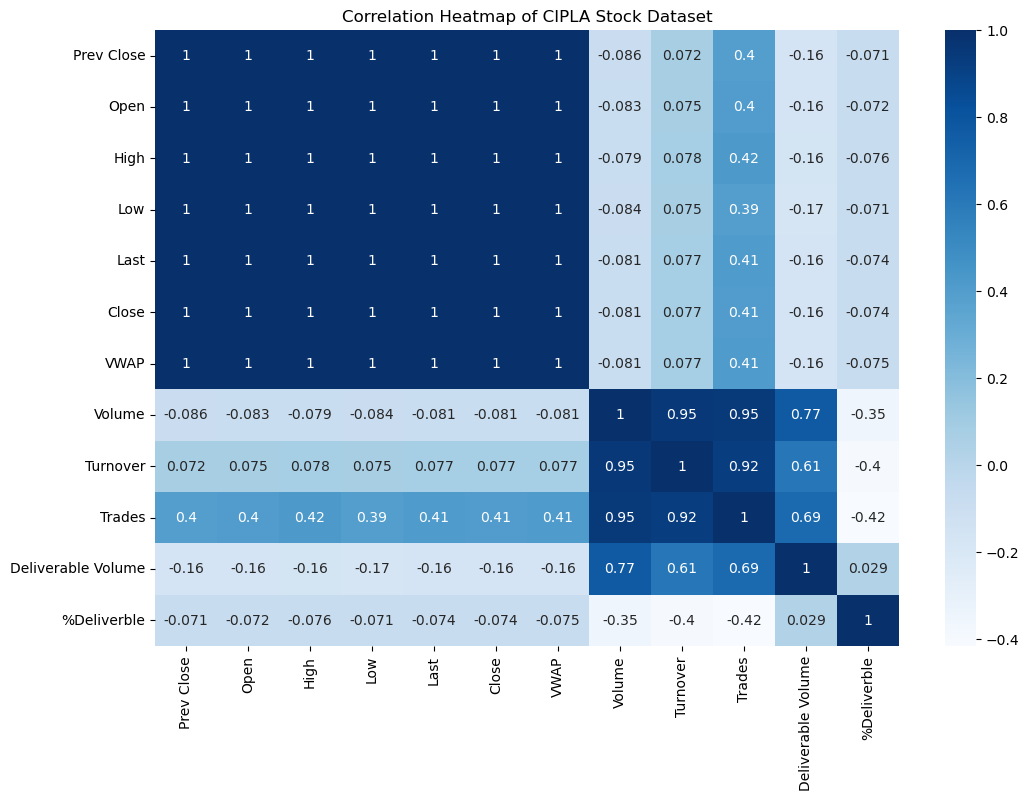

In [9]:
# EDA: Correlation heatmap of numerical columns

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")

plt.title("Correlation Heatmap of CIPLA Stock Dataset")
plt.show()

In [10]:
# Convert Date column into datetime format

df["Date"] = pd.to_datetime(df["Date"])

print("Data types after date conversion:")
print(df.dtypes)

df.head()

Data types after date conversion:
Date                  datetime64[us]
Symbol                           str
Series                           str
Prev Close                   float64
Open                         float64
High                         float64
Low                          float64
Last                         float64
Close                        float64
VWAP                         float64
Volume                         int64
Turnover                     float64
Trades                       float64
Deliverable Volume           float64
%Deliverble                  float64
dtype: object


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,CIPLA,EQ,1349.40,1410.0,1457.35,1380.05,1457.35,1457.35,1441.36,21060,3.035496e+12,NaN,NaN,NaN
1,2000-01-04,CIPLA,EQ,1457.35,1537.0,1537.00,1430.00,1466.05,1465.25,1460.43,30215,4.412698e+12,NaN,NaN,NaN
2,2000-01-05,CIPLA,EQ,1465.25,1474.0,1474.00,1365.00,1441.00,1435.05,1428.11,33799,4.826872e+12,NaN,NaN,NaN
3,2000-01-06,CIPLA,EQ,1435.05,1434.0,1435.00,1349.00,1365.00,1355.85,1390.55,33083,4.600356e+12,NaN,NaN,NaN
4,2000-01-07,CIPLA,EQ,1355.85,1370.0,1389.90,1247.40,1247.40,1247.55,1267.49,66536,8.433351e+12,NaN,NaN,NaN


In [12]:
# Sort the dataset by Date so the sequence is in correct order

df = df.sort_values(by="Date")
df = df.reset_index(drop=True)

print("First date after sorting:", df["Date"].min())
print("Last date after sorting:", df["Date"].max())

df.head()

First date after sorting: 2000-01-03 00:00:00
Last date after sorting: 2021-04-30 00:00:00


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,CIPLA,EQ,1349.40,1410.0,1457.35,1380.05,1457.35,1457.35,1441.36,21060,3.035496e+12,NaN,NaN,NaN
1,2000-01-04,CIPLA,EQ,1457.35,1537.0,1537.00,1430.00,1466.05,1465.25,1460.43,30215,4.412698e+12,NaN,NaN,NaN
2,2000-01-05,CIPLA,EQ,1465.25,1474.0,1474.00,1365.00,1441.00,1435.05,1428.11,33799,4.826872e+12,NaN,NaN,NaN
3,2000-01-06,CIPLA,EQ,1435.05,1434.0,1435.00,1349.00,1365.00,1355.85,1390.55,33083,4.600356e+12,NaN,NaN,NaN
4,2000-01-07,CIPLA,EQ,1355.85,1370.0,1389.90,1247.40,1247.40,1247.55,1267.49,66536,8.433351e+12,NaN,NaN,NaN


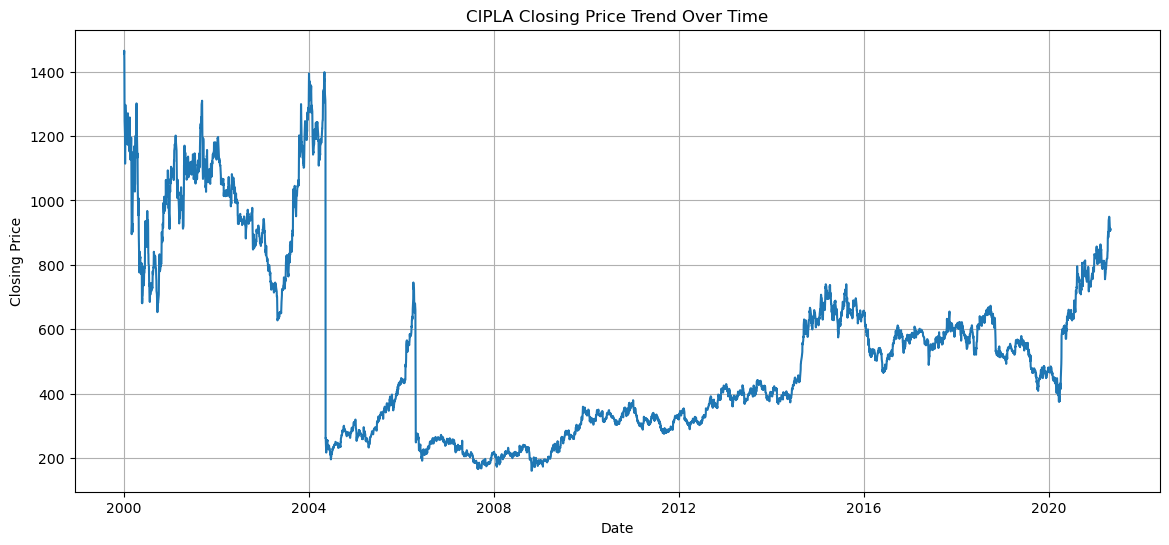

In [14]:
# Line plot to show CIPLA closing price trend over time

plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Close"])

plt.title("CIPLA Closing Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)

plt.show()

New date-based columns:


,Date,Close,Year,Month,Day_Name
0,2000-01-03,1457.35,2000,1,Monday
1,2000-01-04,1465.25,2000,1,Tuesday
2,2000-01-05,1435.05,2000,1,Wednesday
3,2000-01-06,1355.85,2000,1,Thursday
4,2000-01-07,1247.55,2000,1,Friday


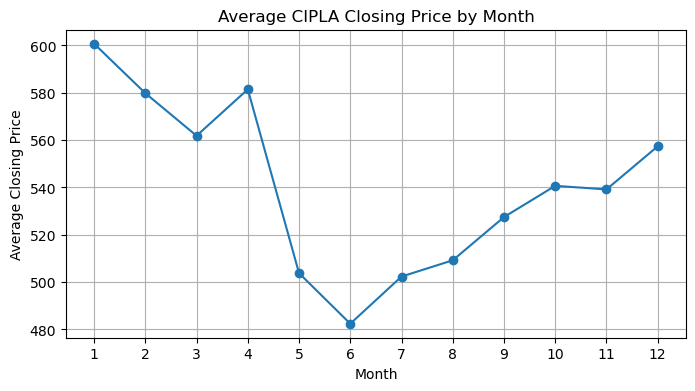

In [16]:
# Pattern checking: Create date-based columns and check monthly pattern

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day_Name"] = df["Date"].dt.day_name()

monthly_pattern = df.groupby("Month")["Close"].mean()

print("New date-based columns:")
display(df[["Date", "Close", "Year", "Month", "Day_Name"]].head())

plt.figure(figsize=(8, 4))
plt.plot(monthly_pattern.index, monthly_pattern.values, marker="o")

plt.title("Average CIPLA Closing Price by Month")
plt.xlabel("Month")
plt.ylabel("Average Closing Price")
plt.xticks(range(1, 13))
plt.grid(True)

plt.show()

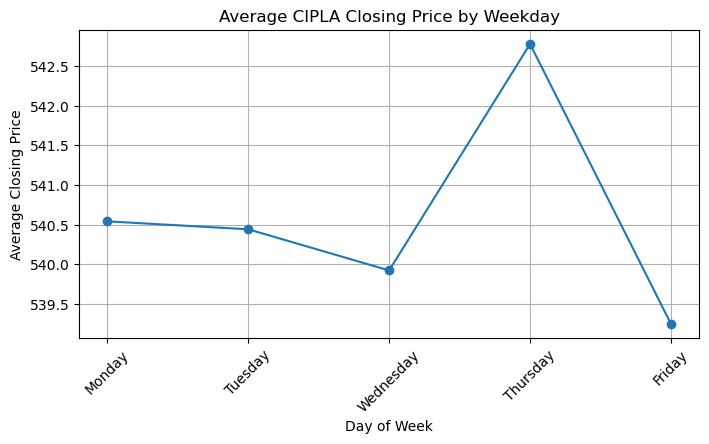

Weekday Pattern Values:
Day_Name
Monday       540.543324
Tuesday      540.443079
Wednesday    539.924647
Thursday     542.777998
Friday       539.249808
Name: Close, dtype: float64


In [17]:
# Pattern checking: Weekday pattern

weekday_pattern = df.groupby("Day_Name")["Close"].mean()

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
weekday_pattern = weekday_pattern.reindex(day_order)

plt.figure(figsize=(8, 4))
plt.plot(weekday_pattern.index, weekday_pattern.values, marker="o")

plt.title("Average CIPLA Closing Price by Weekday")
plt.xlabel("Day of Week")
plt.ylabel("Average Closing Price")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

print("Weekday Pattern Values:")
print(weekday_pattern)